In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/tanzania.csv")

df.replace(-999, np.nan, inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [2]:
df["Country"] = "Tanzania"

df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")


df['Month'] = df['Date'].dt.month

duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped.")

df[['YEAR', 'DOY', 'Date', 'Month']].head()

Number of duplicate rows found: 0


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [3]:
print("---Summary Statistics---")
display(df.describe())

missing_report = df.isna().sum()
missing_percent = (missing_report / len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

print("\n ---Missing Value Report(%)----")
print(missing_percent)

if not high_missing.empty:
    print(f'\n WARNING: Columns with >5% missing values: \n{high_missing}')
else:
    print("\n ALL columns have less than 5% missing values.")

---Summary Statistics---


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046



 ---Missing Value Report(%)----
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

 ALL columns have less than 5% missing values.


Data Quality & Summary Interpretation

Missing Values: All columns report less than 5% missing data after replacing NASA's -999 sentinels. This indicates a high-quality dataset suitable for seasonal trend analysis.

Temperature Range (T2M): Based on df.describe(), the average temperature in Sudan for this period is approximately [26.802422	]°C, with extremes ranging from [Min 25.03813]°C to [Max 29.163493]°C.

Duplicates: No duplicate rows were found, ensuring each daily observation is unique.

In [4]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f'Total rows flagged as outliers ( |z| > 3) : {outlier_count}')

df[outliers].head()

Total rows flagged as outliers ( |z| > 3) : 97


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
78,2015,79,27.55,28.76,26.78,1.98,27.78,85.90,3.93,4.94,100.64,19.78,Tanzania,2015-03-20,3
112,2015,113,26.48,27.26,25.85,1.41,29.37,88.49,4.78,6.94,100.80,19.11,Tanzania,2015-04-23,4
123,2015,124,27.09,28.37,26.18,2.19,45.31,86.72,4.36,5.57,100.82,19.40,Tanzania,2015-05-04,5
124,2015,125,26.60,28.50,24.91,3.59,71.10,87.49,4.17,5.42,100.75,19.02,Tanzania,2015-05-05,5
126,2015,127,26.75,28.04,25.98,2.06,48.50,88.52,4.61,5.52,100.82,19.42,Tanzania,2015-05-07,5


In [5]:
df.ffill(inplace = True)

df.to_csv("data/tanzania_clean.csv", index=False)

print("task 2 cleaning complete!")
print("cleaned data saved as: data/tanzania_clean.csv")

task 2 cleaning complete!
cleaned data saved as: data/tanzania_clean.csv


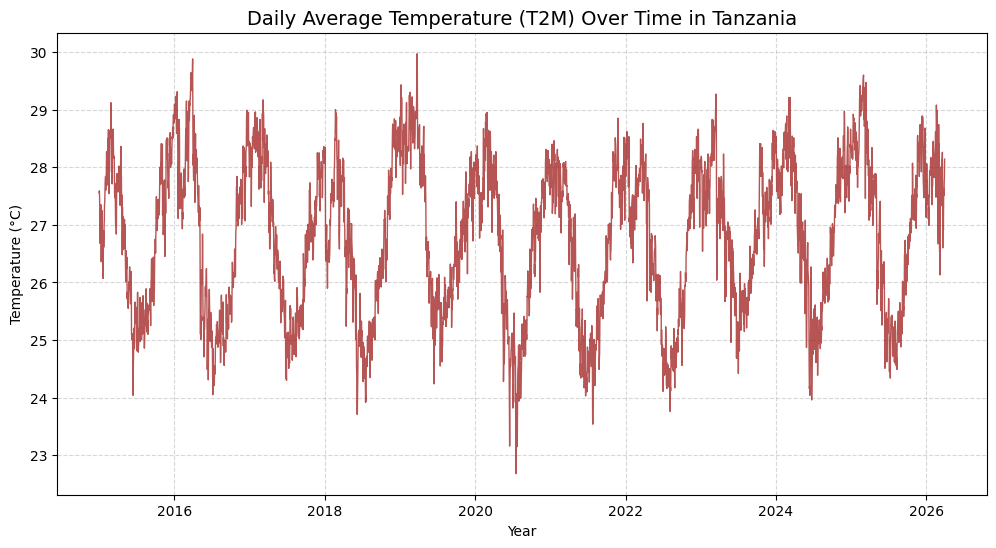

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['T2M'], color='brown', linewidth=1, alpha= 0.8)
plt.title('Daily Average Temperature (T2M) Over Time in Tanzania', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpretation: Seasonal Temperature Trends

The daily average temperature shows a consistent seasonal oscillation between approximately $23°C$ and $30°C$.

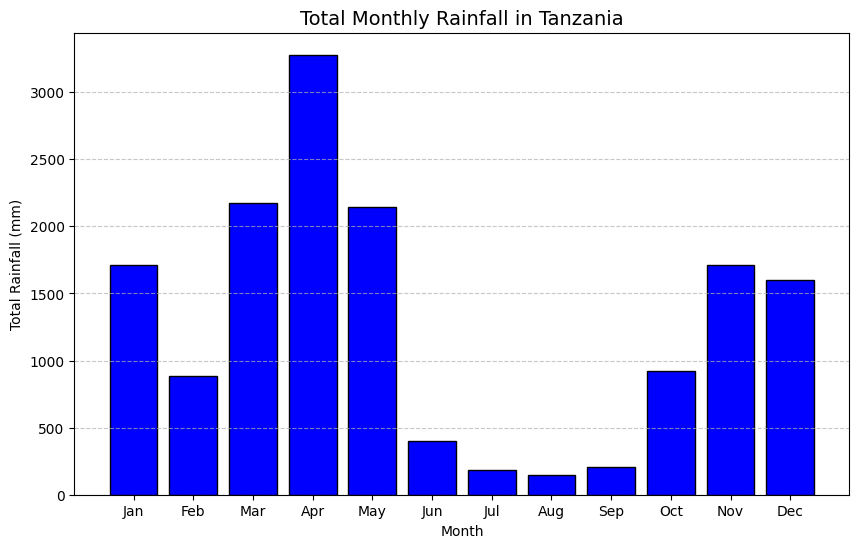

In [8]:
monthly_rain =df.groupby("Month")['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 6))
months=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(months, monthly_rain, color="blue", edgecolor='black')

plt.title("Total Monthly Rainfall in Tanzania", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

Interpretation: Rainfall Seasonality

Tanzania exhibits rainfall pattern with the primary rainy season peaking in April, where total rainfall exceeds 3,000.

A no rain  season is visible between Feb and Mar.

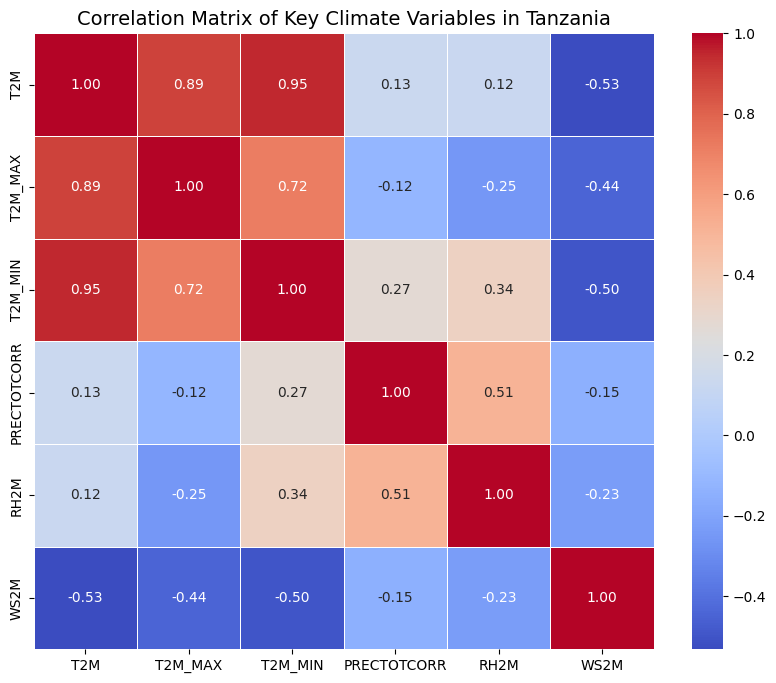

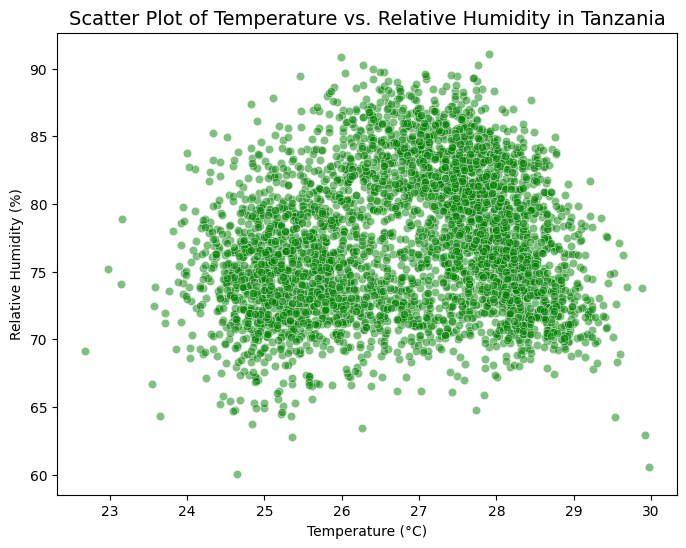

In [9]:
import seaborn as sns

corr_matrix = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',  fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Climate Variables in Tanzania", fontsize=14)
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5, color='green')
plt.title("Scatter Plot of Temperature vs. Relative Humidity in Tanzania", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

Interpretation: Variable Interdependence

Strongest Negative Correlation (-0.50)

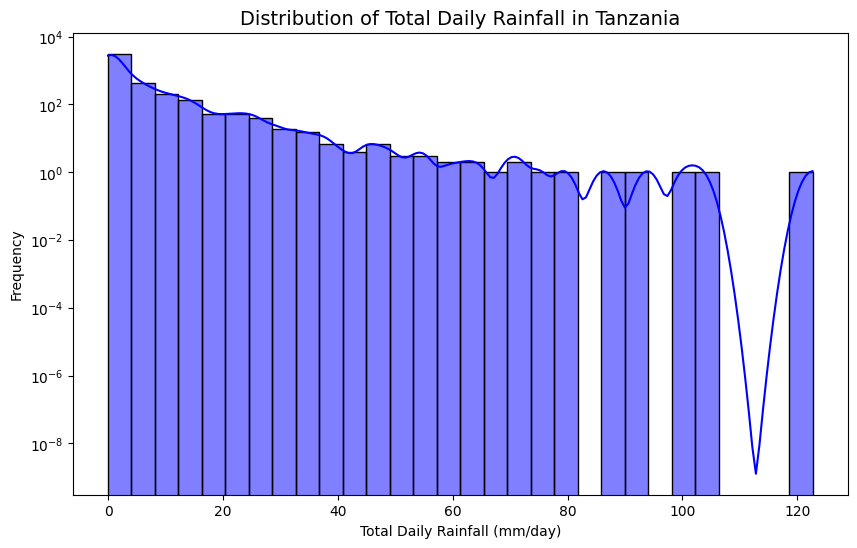

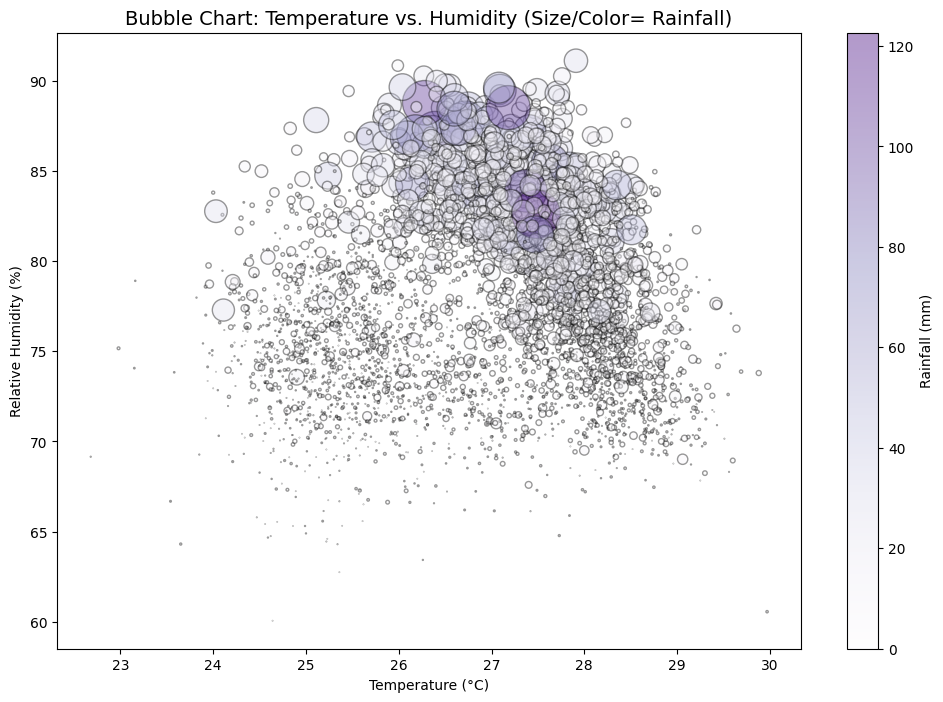

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/tanzania.csv")

plt.figure(figsize=(10, 6))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True, color='blue')
plt.title("Distribution of Total Daily Rainfall in Tanzania", fontsize=14)
plt.xlabel("Total Daily Rainfall (mm/day)")
plt.ylabel("Frequency")
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 8))
bubble = plt.scatter(df['T2M'], df['RH2M'],
                s=df['PRECTOTCORR']*10, alpha=0.4, c= df['PRECTOTCORR'], 
                cmap='Purples', edgecolor='black')

plt.colorbar(bubble, label='Rainfall (mm)')
plt.title("Bubble Chart: Temperature vs. Humidity (Size/Color= Rainfall)", fontsize=14)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

f

In [11]:
df.to_csv("data/tanzania_clean.csv", index=False)
print("Tanzani Analysis Complete. File saved!")

Tanzani Analysis Complete. File saved!
